# Model Evaluation — ConvNeXt-Small

Comprehensive Evaluation of the trained emotion classifier on the held-out test set. 

## 1. Setup & Inference

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.amp import autocast
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, top_k_accuracy_score,
)
from sklearn.preprocessing import label_binarize

In [2]:
_cwd = Path(os.getcwd())
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
data_path = PROJECT_ROOT / "data" / "dataset_split_rafdb"
model_save_path = PROJECT_ROOT / "convnext_small_rafdb.pth"
images_path = PROJECT_ROOT / "images"
images_path.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("Device:", device)
print("Project root:", PROJECT_ROOT)
print("Images dir:", images_path)

Device: cuda
Project root: /home/sera/Projects/image_emotion_detection
Images dir: /home/sera/Projects/image_emotion_detection/images


In [3]:
val_tfms = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(data_path / "test", transform=val_tfms)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

classes = test_dataset.classes
n_classes = len(classes)
print("Classes:", classes)
print("Test samples:", len(test_dataset))

Classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Test samples: 3068


In [4]:
model = models.convnext_small(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, n_classes)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model = model.to(device).eval()
print("Model loaded from", model_save_path)

Model loaded from /home/sera/Projects/image_emotion_detection/convnext_small_rafdb.pth


In [5]:
all_probs, all_probs_tta, all_labels = [], [], []

with torch.inference_mode():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        with autocast(device.type, enabled=use_amp):
            logits = model(inputs)
            logits_tta = (logits + model(TF.hflip(inputs))) / 2
        all_probs.append(F.softmax(logits, dim=1).cpu())
        all_probs_tta.append(F.softmax(logits_tta, dim=1).cpu())
        all_labels.append(labels)

all_probs     = torch.cat(all_probs).numpy()      # (N, C)
all_probs_tta = torch.cat(all_probs_tta).numpy()  # (N, C)
all_labels    = torch.cat(all_labels).numpy()      # (N,)

all_preds     = all_probs.argmax(axis=1)
all_preds_tta = all_probs_tta.argmax(axis=1)

print(f"Inference complete — {len(all_labels)} samples")

Inference complete — 3068 samples


## 2. Overall Metrics

In [6]:
summary = {
    "Accuracy":         [accuracy_score(all_labels, all_preds),
                         accuracy_score(all_labels, all_preds_tta)],
    "Macro F1":         [f1_score(all_labels, all_preds,     average="macro"),
                         f1_score(all_labels, all_preds_tta, average="macro")],
    "Weighted F1":      [f1_score(all_labels, all_preds,     average="weighted"),
                         f1_score(all_labels, all_preds_tta, average="weighted")],
    "Macro Precision":  [precision_score(all_labels, all_preds,     average="macro", zero_division=0),
                         precision_score(all_labels, all_preds_tta, average="macro", zero_division=0)],
    "Macro Recall":     [recall_score(all_labels, all_preds,     average="macro"),
                         recall_score(all_labels, all_preds_tta, average="macro")],
}

df_summary = pd.DataFrame(summary, index=["No TTA", "TTA"]).T
df_summary.columns.name = None
df_summary.style.format("{:.4f}").set_caption("Overall metrics")

,No TTA,TTA
Accuracy,0.8201,0.8171
Macro F1,0.7460,0.7476
Weighted F1,0.8255,0.8225
Macro Precision,0.7209,0.7226
Macro Recall,0.7805,0.7821


## 3. Per-Class Metrics

In [7]:
report = classification_report(
    all_labels, all_preds_tta,
    target_names=classes,
    output_dict=True,
    zero_division=0,
)
df_report = (
    pd.DataFrame(report)
    .T.loc[classes + ["macro avg", "weighted avg"]]
    .drop(columns="support", errors="ignore")
)
df_report.style.format("{:.4f}").bar(
    subset=["precision", "recall", "f1-score"], vmin=0, vmax=1
).set_caption("Per-class metrics (with TTA)")

,precision,recall,f1-score
angry,0.6984,0.8148,0.7521
disgusted,0.5047,0.6687,0.5753
fearful,0.5169,0.6216,0.5644
happy,0.9839,0.8245,0.8972
neutral,0.7880,0.7926,0.7903
sad,0.7860,0.8682,0.8250
surprised,0.7802,0.8845,0.8291
macro avg,0.7226,0.7821,0.7476
weighted avg,0.8365,0.8171,0.8225


## 4. Confusion Matrix

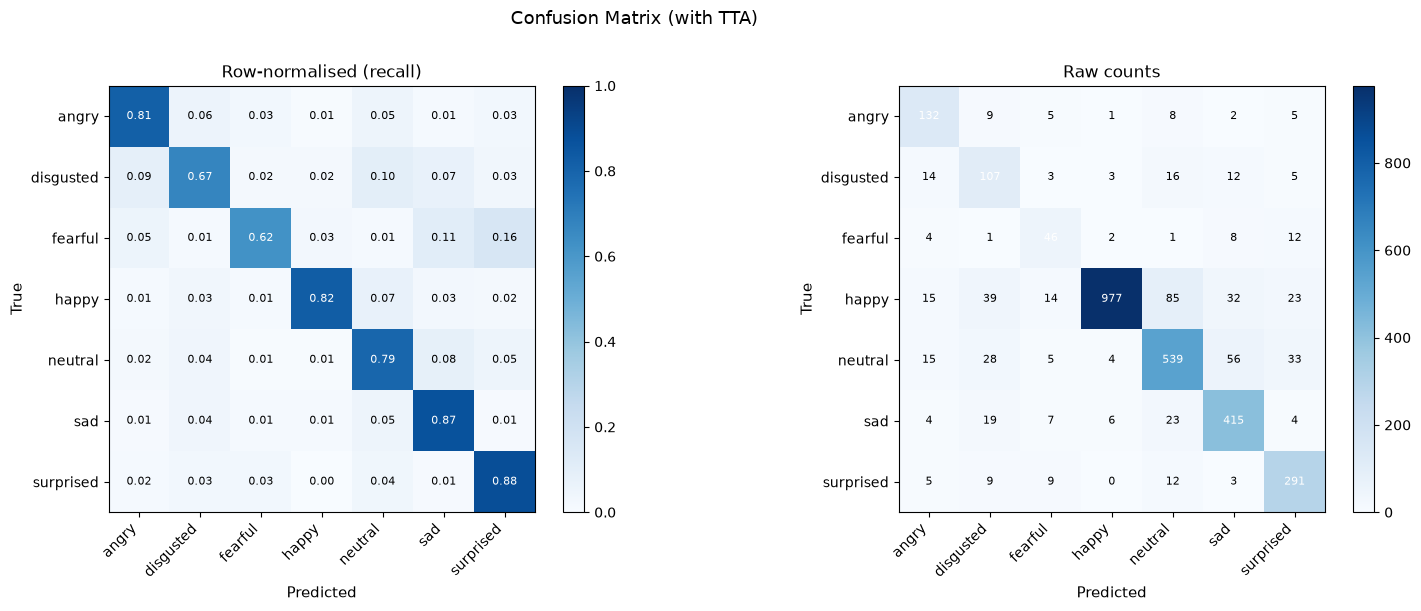

In [8]:
cm = confusion_matrix(all_labels, all_preds_tta)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in [
    (axes[0], cm_norm, "Row-normalised (recall)", "{:.2f}"),
    (axes[1], cm,      "Raw counts",              "{:d}"),
]:
    vmax = 1.0 if data is cm_norm else None
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontsize=12)
    for r in range(n_classes):
        for c in range(n_classes):
            color = "white" if cm_norm[r, c] > 0.5 else "black"
            val = data[r, c]
            ax.text(c, r, fmt.format(val),
                    ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Confusion Matrix (with TTA)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(images_path / "confusion_matrix_eval_rafdb.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. ROC Curves & AUC (One-vs-Rest)

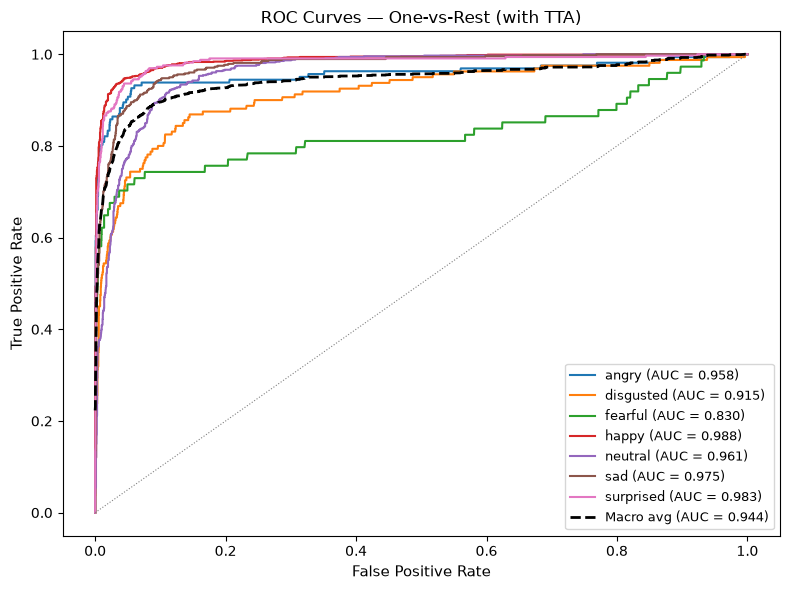

In [9]:
y_bin = label_binarize(all_labels, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs_tta[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.5, label=f"{cls} (AUC = {roc_auc:.3f})")

# Macro-average ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_bin[:, i], all_probs_tta[:, i])[0] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], all_probs_tta[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, "k--", linewidth=2, label=f"Macro avg (AUC = {macro_auc:.3f})")

ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — One-vs-Rest (with TTA)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(images_path / "roc_curves_rafdb.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Confidence Calibration

Expected Calibration Error (ECE): 0.1680


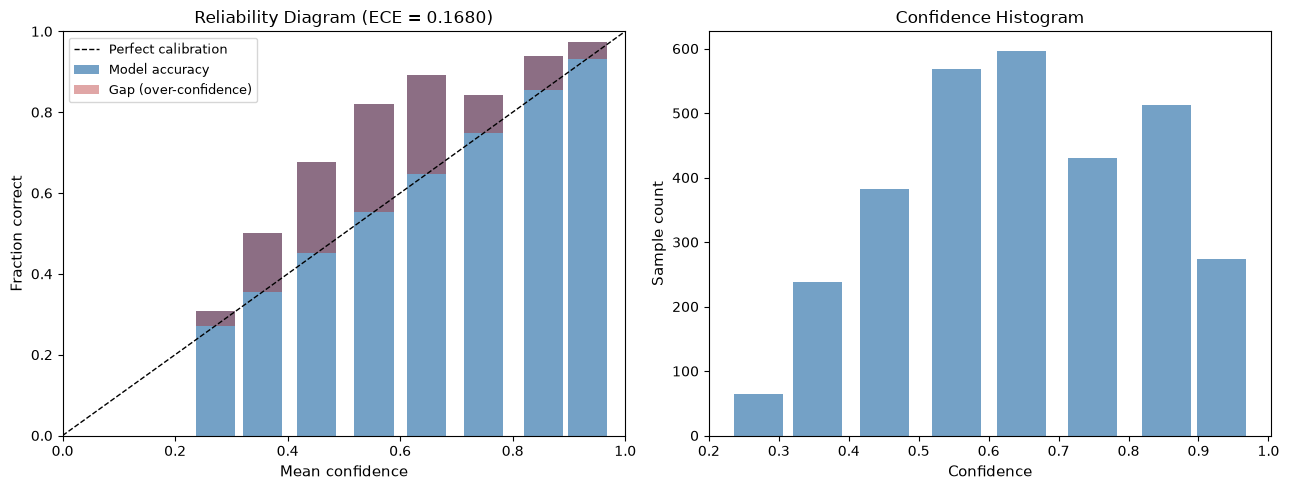

In [10]:
def reliability_diagram(probs: np.ndarray, labels: np.ndarray, n_bins: int = 10):
    confidences = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_conf, bin_acc, bin_counts = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        bin_conf.append(confidences[mask].mean())
        bin_acc.append(correct[mask].mean())
        bin_counts.append(int(mask.sum()))

    ece = sum(
        cnt * abs(acc - conf)
        for acc, conf, cnt in zip(bin_acc, bin_conf, bin_counts)
    ) / len(labels)

    return np.array(bin_conf), np.array(bin_acc), np.array(bin_counts), ece


bin_conf, bin_acc, bin_counts, ece = reliability_diagram(all_probs_tta, all_labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
width = 0.07
ax.bar(bin_conf, bin_acc, width=width, alpha=0.75, label="Model accuracy", color="steelblue")
ax.bar(bin_conf, bin_conf - bin_acc, width=width, bottom=bin_acc,
       alpha=0.4, color="firebrick", label="Gap (over-confidence)")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Mean confidence", fontsize=11)
ax.set_ylabel("Fraction correct", fontsize=11)
ax.set_title(f"Reliability Diagram (ECE = {ece:.4f})", fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(bin_conf, bin_counts, width=width, color="steelblue", alpha=0.75)
ax.set_xlabel("Confidence", fontsize=11)
ax.set_ylabel("Sample count", fontsize=11)
ax.set_title("Confidence Histogram", fontsize=12)

plt.tight_layout()
plt.savefig(images_path / "calibration_rafdb.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confidence Distribution — Correct vs. Incorrect

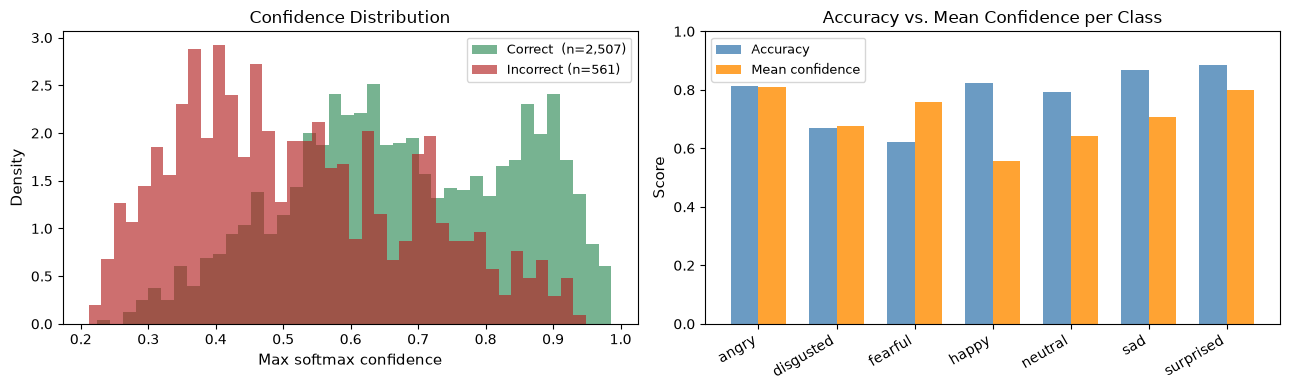

Mean confidence — correct: 0.6782 | incorrect: 0.5186


In [11]:
correct_mask = all_preds_tta == all_labels
conf_all = all_probs_tta.max(axis=1)
conf_correct = conf_all[correct_mask]
conf_wrong = conf_all[~correct_mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(conf_correct, bins=40, alpha=0.65, density=True,
        label=f"Correct  (n={correct_mask.sum():,})", color="seagreen")
ax.hist(conf_wrong,   bins=40, alpha=0.65, density=True,
        label=f"Incorrect (n={(~correct_mask).sum():,})", color="firebrick")
ax.set_xlabel("Max softmax confidence", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Confidence Distribution", fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
per_class_conf = [
    conf_all[all_labels == i].mean() for i in range(n_classes)
]
per_class_acc = [
    (all_preds_tta[all_labels == i] == i).mean() for i in range(n_classes)
]
x = np.arange(n_classes)
w = 0.35
ax.bar(x - w / 2, per_class_acc,  width=w, label="Accuracy",        alpha=0.8, color="steelblue")
ax.bar(x + w / 2, per_class_conf, width=w, label="Mean confidence",  alpha=0.8, color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha="right", fontsize=10)
ax.set_ylim(0, 1)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Accuracy vs. Mean Confidence per Class", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(images_path / "confidence_distribution_rafdb.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence — correct: {conf_correct.mean():.4f} | incorrect: {conf_wrong.mean():.4f}")

## 8. Top-k Accuracy

/home/sera/Projects/image_emotion_detection/venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:2221: UndefinedMetricWarning: 'k' (7) greater than or equal to 'n_classes' (7) will result in a perfect score and is therefore meaningless.
  warnings.warn(
/home/sera/Projects/image_emotion_detection/venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:2221: UndefinedMetricWarning: 'k' (7) greater than or equal to 'n_classes' (7) will result in a perfect score and is therefore meaningless.
  warnings.warn(


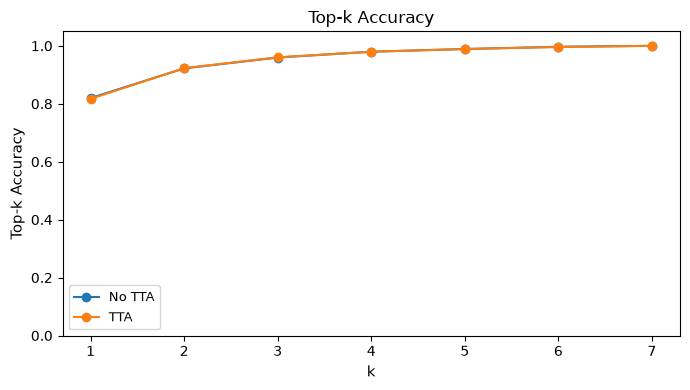

,No TTA,TTA
k,,
1,0.8198,0.8168
2,0.9221,0.9231
3,0.9596,0.9602
4,0.9798,0.9795
5,0.9889,0.9889
6,0.9967,0.9958
7,1.0000,1.0000


In [12]:
rows = []
for k in range(1, n_classes + 1):
    topk_no_tta = top_k_accuracy_score(all_labels, all_probs,     k=k)
    topk_tta    = top_k_accuracy_score(all_labels, all_probs_tta, k=k)
    rows.append({"k": k, "No TTA": topk_no_tta, "TTA": topk_tta})

df_topk = pd.DataFrame(rows).set_index("k")

fig, ax = plt.subplots(figsize=(7, 4))
df_topk.plot(ax=ax, marker="o")
ax.set_xlabel("k", fontsize=11)
ax.set_ylabel("Top-k Accuracy", fontsize=11)
ax.set_title("Top-k Accuracy", fontsize=12)
ax.set_xticks(range(1, n_classes + 1))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(images_path / "topk_accuracy_rafdb.png", dpi=150, bbox_inches="tight")
plt.show()

df_topk.style.format("{:.4f}").set_caption("Top-k accuracy")